### SMOTE for Imbalanced Data

In [1]:
# System Libraries
import re 
import os 
import unicodedata
import itertools


# Library for file manipulation
import pandas as pd 
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Data Visualization 
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration for graphs width and layout of graphs
sns.set_theme(style = 'whitegrid')
palette = 'viridis'

# Warnings remove warnings
import warnings
warnings.filterwarnings("ignore")

# MLflow setup: local sqlite backend for tracking and artifacts in ./mlruns
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm
MLFLOW_EXPERIMENT_NAME = "churn_prediction_experiment_with_smote"
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

def mlflow_log_model(model, name, artifact_path='model'):
    if 'XGB' in type(model).__name__:
        mlflow.xgboost.log_model(model, artifact_path=artifact_path)
    elif 'LGBM' in type(model).__name__:
        mlflow.lightgbm.log_model(model, artifact_path=artifact_path)
    else:
        mlflow.sklearn.log_model(model, artifact_path=artifact_path)


2026/09/16 13:14:10 INFO mlflow.tracking.fluent: Experiment with name 'churn_prediction_experiment_with_smote' does not exist. Creating a new experiment.


In [2]:
# Database

# Set Pandas options to display all columns and rows
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

DATA_PATH = "../data/processed/churn_processed.csv"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head(5)

Shape: (10127, 20)


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,0,45,1,3,3,1,2,0,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,0,49,0,5,2,2,4,0,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,0,51,1,3,2,1,3,0,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,0,40,0,4,3,3,4,0,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,0,40,1,3,5,1,2,0,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  int64  
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  int64  
 3   Dependent_count           10127 non-null  int64  
 4   Education_Level           10127 non-null  int64  
 5   Marital_Status            10127 non-null  int64  
 6   Income_Category           10127 non-null  int64  
 7   Card_Category             10127 non-null  int64  
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              10127 non-null  float64
 13  Total_Revolving_Bal       10127 non-null  int64  
 14  Avg_Op

In [4]:
X = df.drop('Attrition_Flag' , axis = 1)
y = df['Attrition_Flag']

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X , y , stratify = y , test_size = 0.2 , random_state = 42)

In [6]:
from imblearn.over_sampling import SMOTENC

categorical_cols = ['Gender', 'Education_Level', 'Marital_Status','Income_Category', 'Card_Category']

categorical_indices = [
    X_train.columns.get_loc(col)
    for col in categorical_cols
]

smote_nc = SMOTENC(
    categorical_features=categorical_indices,
    random_state=42
)

X_train_smote, y_train_smote = smote_nc.fit_resample(
    X_train,
    y_train
)

mlflow.log_param('smote_random_state', 42)
mlflow.log_param('smote_categorical_cols', categorical_cols)
mlflow.log_metric('train_rows_before_smote', X_train.shape[0])
mlflow.log_metric('train_rows_after_smote', X_train_smote.shape[0])


In [7]:
print("Before SMOTENC:")
print(y_train.value_counts())

print("\nAfter SMOTENC:")
print(y_train_smote.value_counts())

Before SMOTENC:
Attrition_Flag
0    6799
1    1302
Name: count, dtype: int64

After SMOTENC:
Attrition_Flag
0    6799
1    6799
Name: count, dtype: int64


#### Model training and testing 

In [8]:
# Importing libraries
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier, plot_importance as plot_importance_xgb
from sklearn.naive_bayes import GaussianNB
from lightgbm import LGBMClassifier, plot_importance as plot_importance_lgbm
import matplotlib.pyplot as plt

# Metrics and model evaluation
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score, classification_report

In [9]:
# Dictionary of models
models = { 
    # Logistic Regression model
    "Logistic Regression": LogisticRegression(),
    
    # Naive Bayes model
    "Naive Bayes": GaussianNB(),
       
    # Decision Tree model
    "Decision Tree Classifier": DecisionTreeClassifier(),
    
    # Random Forest model
    "Random Forest": RandomForestClassifier(),
    
    # AdaBoost model
    "AdaBoost": AdaBoostClassifier(),
    
    # Gradient Boosting model
    "Gradient Boosting": GradientBoostingClassifier(),
    
    # XGBoost model
    "XGBoost": XGBClassifier(),
    
    # LightGBM model
    "LightGBM": LGBMClassifier()
}

In [13]:
# Model training with tqdm
mlflow.start_run(run_name='SMOTE' , nested=True)
mlflow.set_tag('Dataset', 'SMOTE')

for name, model in tqdm(models.items(), desc="Training models", total=len(models)):

    with mlflow.start_run(run_name=name, nested=True):

        mlflow.set_tag('Model', name)
        mlflow.log_params({k: str(v) for k, v in model.get_params().items()})

        # Train model
        model.fit(X_train_smote, y_train_smote)

        # Model score
        score = model.score(X_test, y_test)

        mlflow.log_metric('accuracy', score)
        mlflow_log_model(model, name)

        # Model prediction
        model_pred = model.predict(X_test)

        # Displaying model results
        print()
        tqdm.write(f"Model: {name} has Accuracy {score:.2%}")

mlflow.end_run()


Training models:  12%|█▎        | 1/8 [00:37<04:23, 37.70s/it]2026/09/16 13:16:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Model: Logistic Regression has Accuracy 82.63%


Training models:  25%|██▌       | 2/8 [00:49<02:13, 22.32s/it]


Model: Naive Bayes has Accuracy 76.75%


2026/09/16 13:16:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Training models:  38%|███▊      | 3/8 [01:00<01:26, 17.28s/it]

...


Model: XGBoost has Accuracy 96.45%


2026/09/16 13:17:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[LightGBM] [Info] Number of positive: 6799, number of negative: 6799
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001997 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2047
[LightGBM] [Info] Number of data points in the train set: 13598, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


Training models: 100%|██████████| 8/8 [02:03<00:00, 15.48s/it]


Model: LightGBM has Accuracy 96.10%


In [14]:
mlflow.end_run()


Machine Learning Model: Logistic Regression





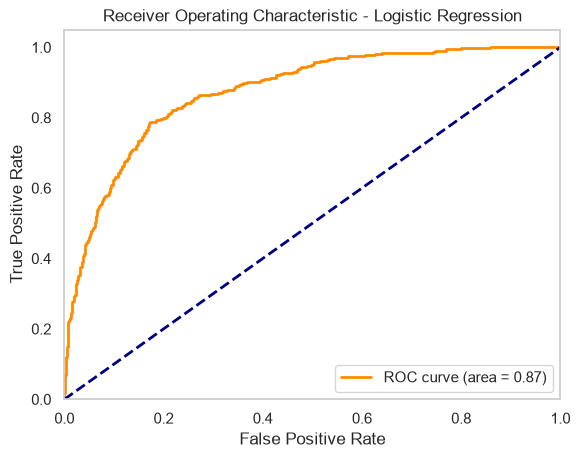



Accuracy: 0.8262586377097729




Confusion matrix 

 [[1431  270]
 [  82  243]]

True Positives (TP) =  1431

True Negatives (TN) =  243

False Positives (FP) =  82

False Negatives (FN) =  270




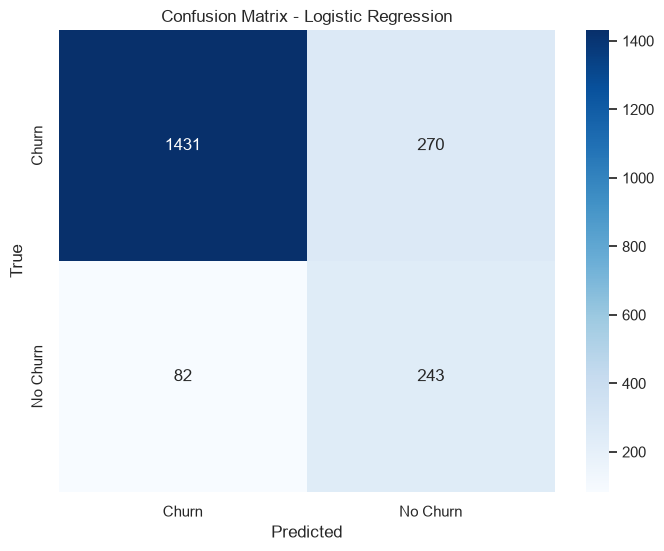



Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.84      0.89      1701
           1       0.47      0.75      0.58       325

    accuracy                           0.83      2026
   macro avg       0.71      0.79      0.74      2026
weighted avg       0.87      0.83      0.84      2026


Machine Learning Model: Naive Bayes





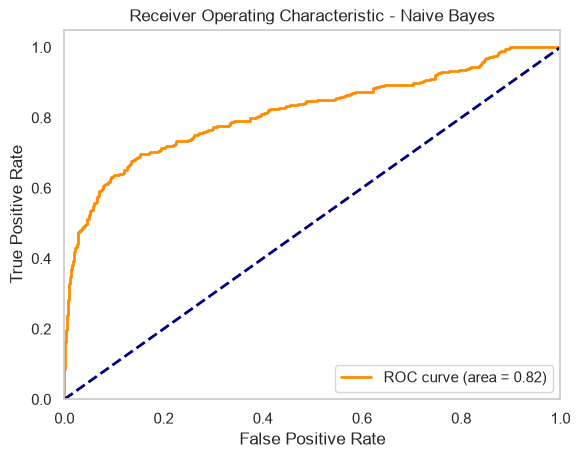



Accuracy: 0.7675222112537019




Confusion matrix 

 [[1318  383]
 [  88  237]]

True Positives (TP) =  1318

True Negatives (TN) =  237

False Positives (FP) =  88

False Negatives (FN) =  383




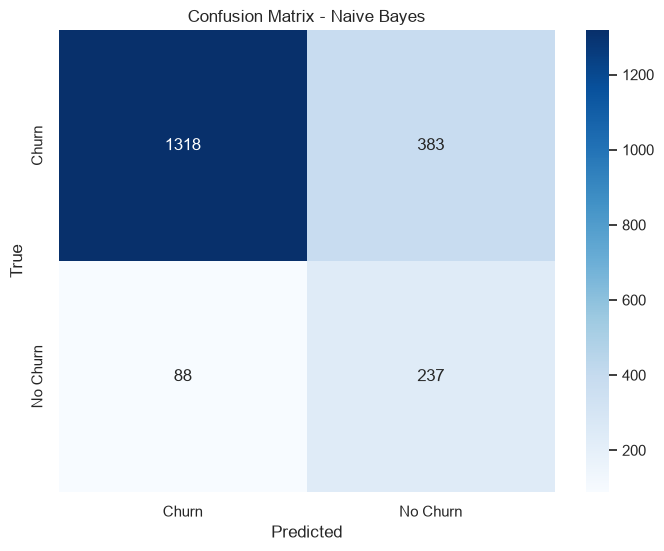



Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.77      0.85      1701
           1       0.38      0.73      0.50       325

    accuracy                           0.77      2026
   macro avg       0.66      0.75      0.67      2026
weighted avg       0.85      0.77      0.79      2026


Machine Learning Model: Decision Tree Classifier





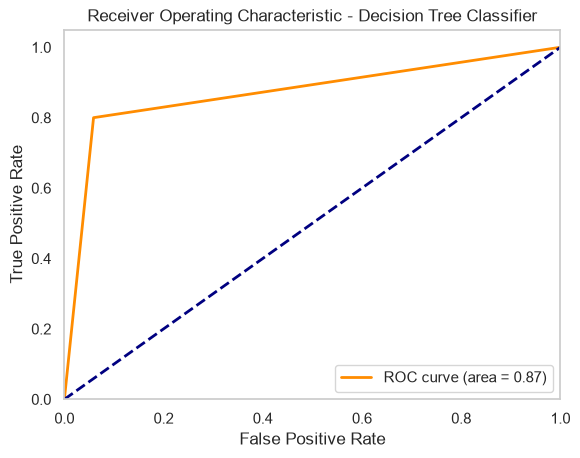



Accuracy: 0.918558736426456




Confusion matrix 

 [[1601  100]
 [  65  260]]

True Positives (TP) =  1601

True Negatives (TN) =  260

False Positives (FP) =  65

False Negatives (FN) =  100




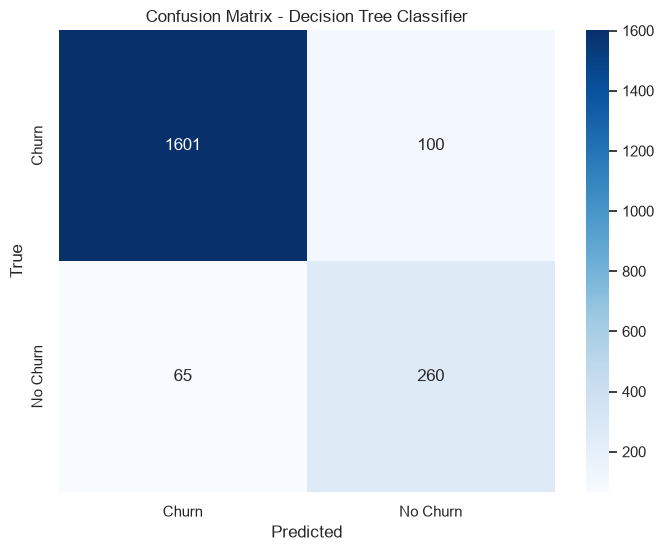



Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      1701
           1       0.72      0.80      0.76       325

    accuracy                           0.92      2026
   macro avg       0.84      0.87      0.86      2026
weighted avg       0.92      0.92      0.92      2026


Machine Learning Model: Random Forest





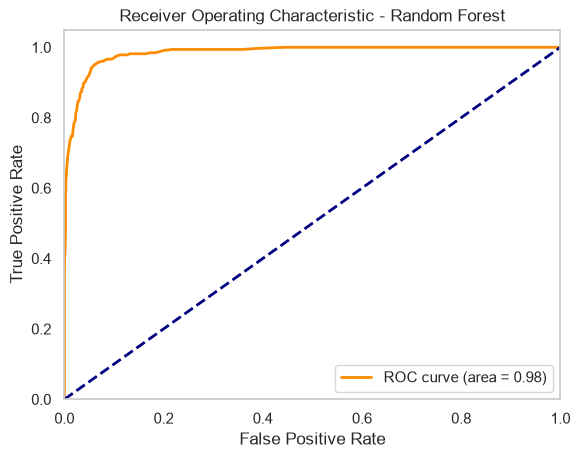



Accuracy: 0.9511352418558736




Confusion matrix 

 [[1648   53]
 [  46  279]]

True Positives (TP) =  1648

True Negatives (TN) =  279

False Positives (FP) =  46

False Negatives (FN) =  53




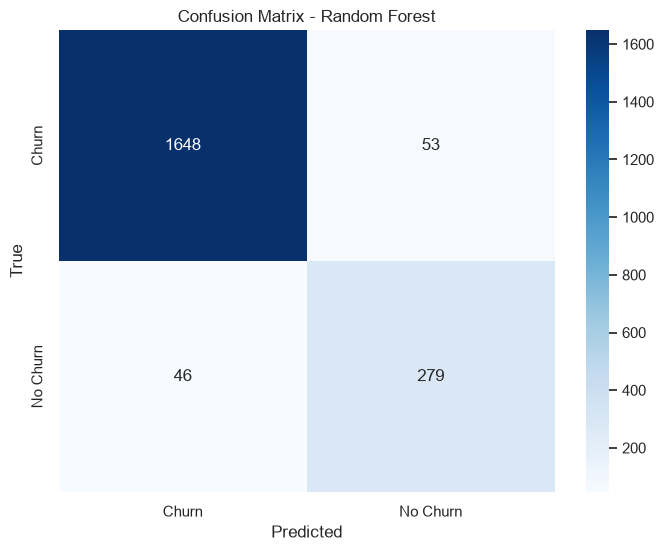



Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1701
           1       0.84      0.86      0.85       325

    accuracy                           0.95      2026
   macro avg       0.91      0.91      0.91      2026
weighted avg       0.95      0.95      0.95      2026


Machine Learning Model: AdaBoost





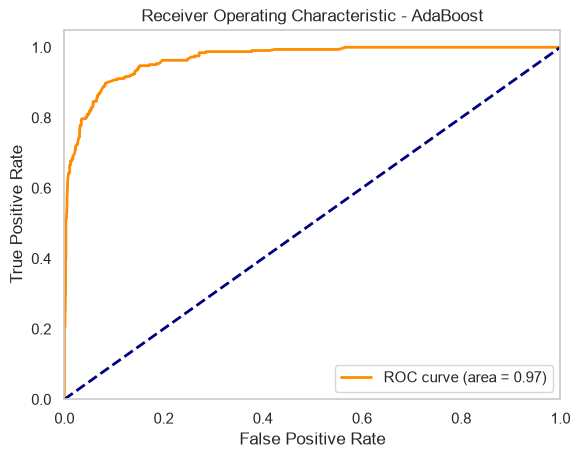



Accuracy: 0.9220138203356367




Confusion matrix 

 [[1588  113]
 [  45  280]]

True Positives (TP) =  1588

True Negatives (TN) =  280

False Positives (FP) =  45

False Negatives (FN) =  113




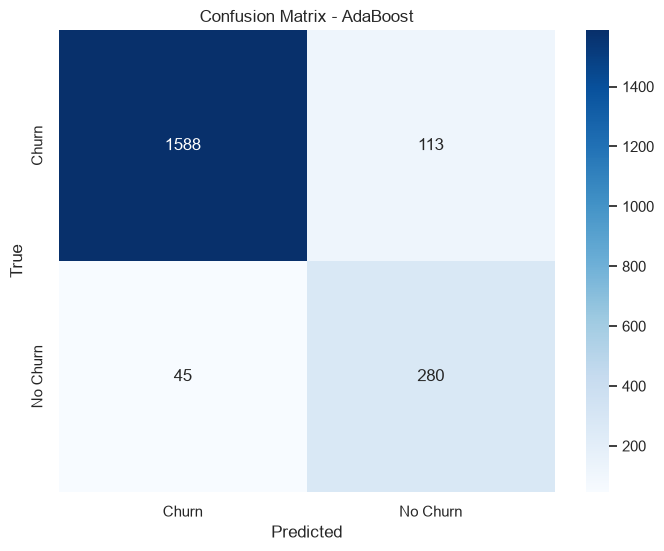



Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      1701
           1       0.71      0.86      0.78       325

    accuracy                           0.92      2026
   macro avg       0.84      0.90      0.87      2026
weighted avg       0.93      0.92      0.92      2026


Machine Learning Model: Gradient Boosting





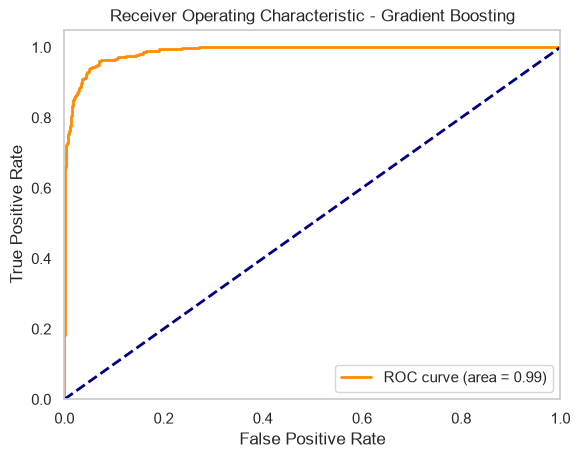



Accuracy: 0.9501480750246791




Confusion matrix 

 [[1628   73]
 [  28  297]]

True Positives (TP) =  1628

True Negatives (TN) =  297

False Positives (FP) =  28

False Negatives (FN) =  73




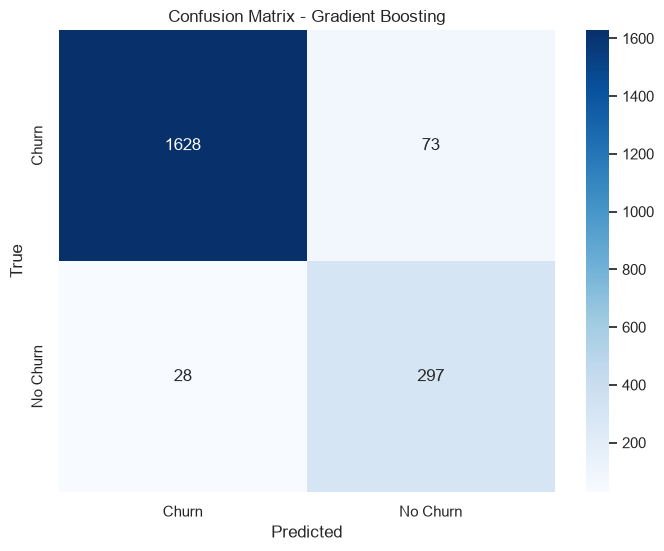



Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1701
           1       0.80      0.91      0.85       325

    accuracy                           0.95      2026
   macro avg       0.89      0.94      0.91      2026
weighted avg       0.95      0.95      0.95      2026


Machine Learning Model: XGBoost





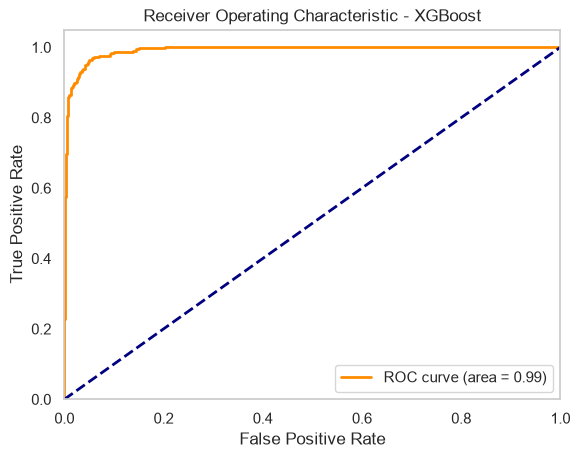



Accuracy: 0.9644619940769991




Confusion matrix 

 [[1661   40]
 [  32  293]]

True Positives (TP) =  1661

True Negatives (TN) =  293

False Positives (FP) =  32

False Negatives (FN) =  40




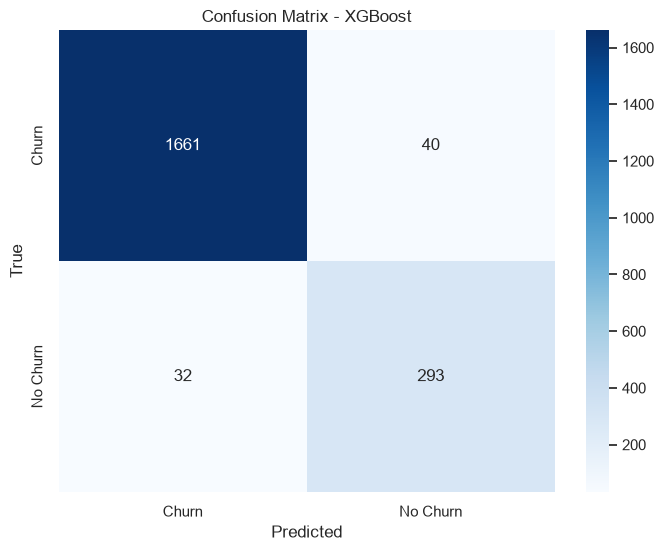



Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1701
           1       0.88      0.90      0.89       325

    accuracy                           0.96      2026
   macro avg       0.93      0.94      0.93      2026
weighted avg       0.96      0.96      0.96      2026

[LightGBM] [Info] Number of positive: 6799, number of negative: 6799
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001083 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2047
[LightGBM] [Info] Number of data points in the train set: 13598, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

Machine Learning Model: LightGBM





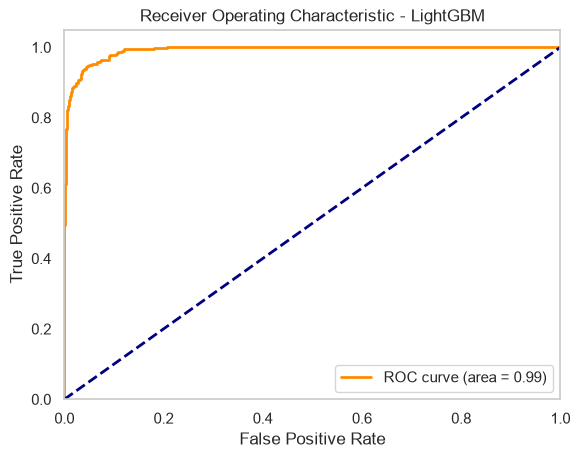



Accuracy: 0.9610069101678184




Confusion matrix 

 [[1652   49]
 [  30  295]]

True Positives (TP) =  1652

True Negatives (TN) =  295

False Positives (FP) =  30

False Negatives (FN) =  49




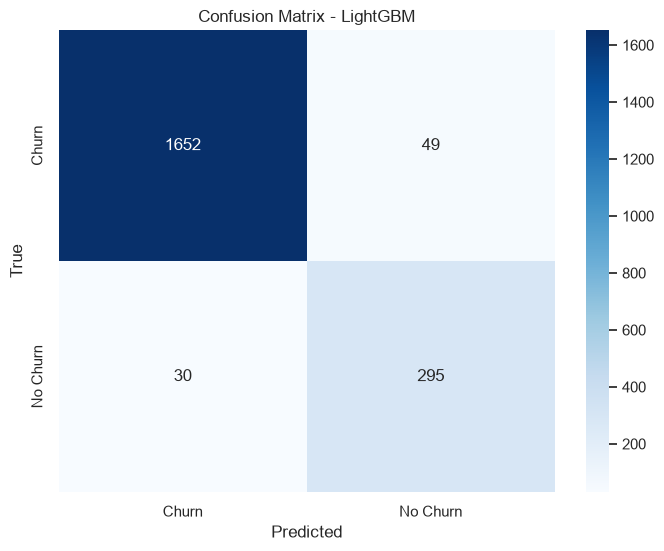



Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1701
           1       0.86      0.91      0.88       325

    accuracy                           0.96      2026
   macro avg       0.92      0.94      0.93      2026
weighted avg       0.96      0.96      0.96      2026



In [15]:
# Iterating over each model
for name, model in models.items():

    with mlflow.start_run(run_name=f"{name}_evaluation", nested=False):

        mlflow.set_tag('Model', name)
        mlflow.set_tag('Dataset', 'SMOTE')
        mlflow.set_tag('Stage', 'evaluation')

        # Training the model
        model.fit(X_train_smote, y_train_smote)

        # Prediction on the test set
        y_pred = model.predict(X_test)

        print()
        print("Machine Learning Model:", name)

        # ROC Curve
        fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
        roc_auc = auc(fpr, tpr)
        mlflow.log_metric('roc_auc', roc_auc)
        print()
        print()
        # Plotting the ROC Curve
        print()
        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic - {}'.format(name))
        plt.legend(loc="lower right")
        plt.grid(False)
        mlflow.log_figure(plt.gcf(), f"roc_curve_{name}.png")
        plt.show()
        print()
        print()

        # Accuracy
        acc = accuracy_score(y_test, y_pred)
        mlflow.log_metric('accuracy', acc)
        print("Accuracy:", acc)
        print()
        print()
        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        print()
        print()
        print('Confusion matrix \n\n', cm)
        print('\nTrue Positives (TP) = ', cm[0,0])
        print('\nTrue Negatives (TN) = ', cm[1,1])
        print('\nFalse Positives (FP) = ', cm[1,0])
        print('\nFalse Negatives (FN) = ', cm[0,1])
        print()
        print()

        # Plotting the confusion matrix with Seaborn
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title('Confusion Matrix - {}'.format(name))
        plt.xlabel('Predicted')
        plt.ylabel('True') 
        plt.xticks(ticks=[0.5, 1.5], labels=['Churn', 'No Churn'])
        plt.yticks(ticks=[0.5, 1.5], labels=['Churn', 'No Churn'])
        mlflow.log_figure(plt.gcf(), f"confusion_matrix_{name}.png")
        plt.show()
        print()
        print()

        # Classification Report
        report_txt = classification_report(y_test, y_pred)
        print("Classification Report:")
        print(report_txt)
        mlflow.log_text(report_txt, f"classification_report_{name}.txt")


### Hyperparameter tuning using GridSearch

In [ ]:
# from xgboost import XGBClassifier
# from sklearn.model_selection import GridSearchCV


# def tune_xgboost(X_train, y_train):
#     """
#     Hyperparameter tuning for XGBoost using GridSearchCV.

#     Returns:
#         best_model: Best fitted XGBoost model
#         best_params: Best hyperparameters
#         best_score: Best cross-validation ROC-AUC score
#     """

#     xgb = XGBClassifier(
#         objective="binary:logistic",
#         eval_metric="logloss",
#         random_state=42,
#         n_jobs=-1
#     )

#     param_grid = {
#         "n_estimators": [100, 200, 300],
#         "max_depth": [3, 5, 7],
#         "learning_rate": [0.01, 0.05, 0.1],
#         "subsample": [0.8, 1.0],
#         "colsample_bytree": [0.8, 1.0]
#     }

#     grid_search = GridSearchCV(
#         estimator=xgb,
#         param_grid=param_grid,
#         scoring="roc_auc",
#         cv=5,
#         n_jobs=-1,
#         verbose=1
#     )

#     grid_search.fit(X_train, y_train)

#     best_model = grid_search.best_estimator_
#     best_params = grid_search.best_params_
#     best_score = grid_search.best_score_

#     print("Best Parameters:")
#     print(best_params)

#     print("\nBest CV ROC-AUC:")
#     print(best_score)

#     return best_model, best_params, best_score

# best_model , best_params , score = tune_xgboost(X_train_smote, y_train_smote)

### Reports

In [16]:
import os
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)


def create_report(path, models, X_test, y_test):

    results = []

    for name, model in models.items():

        # Predictions
        y_pred = model.predict(X_test)

        # Prediction probabilities
        y_prob = model.predict_proba(X_test)[:, 1]

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)

        # Assuming Class 1 = Churn
        tn, fp, fn, tp = cm.ravel()

        # Metrics
        accuracy = accuracy_score(y_test, y_pred)

        roc_auc = roc_auc_score(
            y_test,
            y_prob
        )

        precision = precision_score(
            y_test,
            y_pred,
            pos_label=1
        )

        recall = recall_score(
            y_test,
            y_pred,
            pos_label=1
        )

        f1 = f1_score(
            y_test,
            y_pred,
            pos_label=1
        )

        # Matthews Correlation Coefficient
        mcc = matthews_corrcoef(
            y_test,
            y_pred
        )

        # Store results
        results.append({
            "Model": name,
            "Accuracy": accuracy,
            "ROC_AUC": roc_auc,
            "Precision_Churn": precision,
            "Recall_Churn": recall,
            "F1_Churn": f1,
            "MCC": mcc,
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn
        })

        with mlflow.start_run(run_name=f"{name}_report", nested=False):
            mlflow.set_tag('Model', name)
            mlflow.set_tag('Dataset', 'SMOTE')
            mlflow.set_tag('Stage', 'final_report')
            mlflow.log_metrics({
                'accuracy': accuracy,
                'roc_auc': roc_auc,
                'precision_churn': precision,
                'recall_churn': recall,
                'f1_churn': f1,
                'mcc': mcc
            })
            mlflow.log_metrics({
                'tp': float(tp),
                'tn': float(tn),
                'fp': float(fp),
                'fn': float(fn)
            })

    # Convert to DataFrame
    report_df = pd.DataFrame(results)

    # Sort by F1-score
    report_df = report_df.sort_values(
        by="F1_Churn",
        ascending=False
    )

    # Create directory if required
    os.makedirs(
        os.path.dirname(path),
        exist_ok=True
    )

    # Save CSV
    report_df.to_csv(
        path,
        index=False
    )

    print(f"Report saved successfully at: {path}")

    with mlflow.start_run(run_name="final_report_summary", nested=False):
        mlflow.set_tag('Dataset', 'SMOTE')
        mlflow.set_tag('Stage', 'final_report_summary')
        mlflow.log_artifact(path)

    return report_df

report = create_report(
    "../outputs/metrics/model_report_with_smote.csv",
    models,
    X_test,
    y_test
)


Report saved successfully at: ../outputs/metrics/model_report_with_smote.csv


### Model Comparison: XGBoost vs LightGBM

Since the objective of this project is **credit card customer churn prediction**, the evaluation should focus on the performance of the **Churn class (Class 1)** rather than accuracy alone. In this problem, a **false negative** means failing to identify a customer who will actually churn, which can result in a missed customer-retention opportunity.

**Performance Comparison**

| Model | Sampling | Precision (Churn) | Recall (Churn) | F1-Score (Churn) | Accuracy |
|:---|:---:|---:|---:|---:|---:|
| LightGBM | SMOTE | 0.86 | **0.91** | 0.88 | 0.96 |
| LightGBM | No SMOTE | 0.93 | 0.87 | 0.90 | 0.97 |
| XGBoost | SMOTE | 0.88 | 0.90 | 0.89 | 0.96 |
| **XGBoost** | **No SMOTE** | **0.95** | 0.87 | **0.91** | **0.97** |

**Confusion Matrix Comparison**

| Model | Sampling | TP | TN | FP | FN |
|:---|:---:|---:|---:|---:|---:|
| LightGBM | SMOTE | 295 | 1652 | 49 | 30 |
| LightGBM | No SMOTE | 282 | 1681 | 20 | 43 |
| XGBoost | SMOTE | 293 | 1661 | 32 | 40 |
| **XGBoost** | **No SMOTE** | **283** | **1687** | **14** | **42** |

> **Note:** Here, `Churn = 1` is treated as the positive class. Therefore, TP and FN refer to actual churners, while FP refers to customers incorrectly predicted as churners.

---

**Effect of SMOTE**

SMOTE was applied to address the class imbalance in the training data. The original dataset contains considerably fewer churned customers than existing customers. SMOTE generates synthetic samples for the minority class rather than simply duplicating existing observations.

**XGBoost: Effect of SMOTE**

| Metric | Without SMOTE | With SMOTE | Change |
|:---|---:|---:|---:|
| Churn Precision | **0.95** | 0.88 | ↓ 0.07 |
| Churn Recall | 0.87 | **0.90** | ↑ 0.03 |
| Churn F1-Score | **0.91** | 0.89 | ↓ 0.02 |
| Accuracy | **0.97** | 0.96 | ↓ 0.01 |
| False Positives | **14** | 32 | ↑ 18 |
| False Negatives | 42 | **40** | ↓ 2 |

**Interpretation**

After applying SMOTE to XGBoost:

- **Recall increased** from 87% to 90%, meaning the model identified more actual churners.
- **Precision decreased** from 95% to 88%, meaning more customers were incorrectly classified as potential churners.
- **F1-score decreased** slightly from 91% to 89%.
- Accuracy decreased from 97% to 96%.
- The reduction in false negatives was relatively small (**42 → 40**).

Therefore, for XGBoost, SMOTE improved the model's sensitivity toward churn but did not improve its overall F1-score or precision.

---

**LightGBM vs XGBoost**

For the **non-SMOTE models**, both algorithms achieved 97% accuracy and 87% churn recall.

However:

- XGBoost achieved **95% churn precision** compared with 93% for LightGBM.
- XGBoost achieved **91% churn F1-score** compared with 90% for LightGBM.
- XGBoost produced **14 false positives**, compared with 20 for LightGBM.
- Both models had a similar number of false negatives: XGBoost = 42 and LightGBM = 43.

For the **SMOTE models**, LightGBM achieved slightly higher churn recall:

```text
LightGBM + SMOTE → Recall = 91%
XGBoost + SMOTE   → Recall = 90%

### Conclusion: Final Model Selection

The objective of this project is to predict credit card customer churn and identify
customers who are at risk of leaving the service. Therefore, the performance of the
Churn class (Class 1) is particularly important.

Among the evaluated models, LightGBM with SMOTE achieved the highest Churn recall
of 91%, identifying 295 out of 325 actual churners and reducing false negatives to
30. This makes it useful when the primary objective is to identify as many potential
churners as possible.

However, XGBoost without SMOTE achieved the highest Churn precision (95%) and
Churn F1-score (91%), while producing only 14 false positives. This indicates that
its churn predictions are more precise and that fewer customers would be incorrectly
flagged for retention interventions.

Therefore, model selection depends on the business objective. If the cost of
missing a potential churner is high, LightGBM with SMOTE is preferable because it
provides the highest churn recall. If the business wants highly precise churn
predictions and wants to minimize unnecessary retention interventions, XGBoost
without SMOTE provides a stronger precision/F1 trade-off.

For this churn prediction problem, **Churn Recall should be given particular
importance because identifying customers at risk of leaving enables the business
to take proactive retention actions.**

**I wouldn't select the model based on accuracy alone. Since this is a churn prediction problem, I focused on the minority churn class. LightGBM with SMOTE gives the highest churn recall at 91%, so it identifies the largest proportion of actual churners. XGBoost without SMOTE, however, gives 95% precision and 91% F1-score, so its churn predictions are more precise. The final choice depends on the relative business cost of missing a churner versus unnecessarily targeting a customer for retention.**